L'idée est de créer la partie modèle avec HMM + LSTM

In [ ]:
# --- ÉTAPE 1 : CREATION DU DATASET ---
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import warnings
import random
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Conv1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Chargement des rendements purs (issus du Module 2)
returns = pd.read_csv('../data/processed/chip_chain_returns.csv', index_col=0, parse_dates=True)
prices = pd.read_csv('../data/processed/chip_chain_prices.csv', index_col=0, parse_dates=True)

# 2. FEATURE ENGINEERING (Sélection des indicateurs clés)
df_features = pd.DataFrame(index=returns.index)

# A. Les signaux bruts de la Supply Chain
df_features['Ret_NVDA'] = returns['NVDA']
df_features['Ret_SMIC'] = returns['0981.HK']
df_features['Ret_VIX'] = returns['^VIX']
df_features['Ret_TNX'] = returns['^TNX']

# B. Les Z-Scores et Spreads (Pour capter l'écartement de la chaîne)
def calc_zscore(serie_a, serie_b, window=63):
    spread = serie_a - serie_b
    mean = spread.rolling(window=window).mean()
    std = spread.rolling(window=window).std()
    zscore = (spread - mean) / std
    return zscore
df_features['Spread_Macro_Foundry_Fabless'] = returns['TSM'] - returns['NVDA']
df_features['Zscore_NVDA_AMD'] = calc_zscore(returns['NVDA'], returns['AMD'], 21)
df_features['Spread_Safe_Haven'] = returns['GLD'] - returns['^TNX']

# C. L'historique de la Volatilité (La mémoire du marché)
df_features['RV_NVDA_21d'] = returns['NVDA'].rolling(window=21).std() * np.sqrt(252)
df_features['RV_VIX_21d'] = returns['^VIX'].rolling(window=21).std() * np.sqrt(252)

df_features['TNX_Diff'] = prices['^TNX'].diff()

# 3. LA TARGET (Volatilité Continue Future)
HORIZON_VOL = 21
df_features['RV_future_21d'] = (
    returns['NVDA']
    .rolling(window=21)
    .std()
    .shift(-21)           # on shift après rolling et pas avant
    * np.sqrt(252)
)

df_features['Target_Delta_RV'] = (
    df_features['RV_future_21d'] - df_features['RV_NVDA_21d']
)

df_features = df_features.drop(columns='RV_future_21d')

df_features = df_features.dropna()

Pour éviter un problème de non convergence :
- on normalise les inputs du HMM (Scaler)
- on ajoute un plancher de covariance (min_covar)

In [ ]:
# --- ÉTAPE 2 : LE HMM WALK-FORWARD ---
# On utilise les rendements de NVDA et le VIX pour détecter la "peur"
hmm_features = df_features[['Ret_NVDA', 'Ret_VIX']].values
df_features['HMM_State'] = np.nan

# On scale les features avant le HMM mais la partie test
split_idx_hmm = int(len(df_features) * 0.8)

scaler_hmm = StandardScaler()
hmm_train_scaled = scaler_hmm.fit_transform(
    df_features.iloc[:split_idx_hmm][['Ret_NVDA', 'Ret_VIX']].values
)
hmm_test_scaled = scaler_hmm.transform(
    df_features.iloc[split_idx_hmm:][['Ret_NVDA', 'Ret_VIX']].values
)
hmm_features_scaled = np.vstack([hmm_train_scaled, hmm_test_scaled])


warmup_period = 252 # 1 an de chauffe
n_states = 2

# Pour éviter que la boucle prenne 1 heure, on ré-entraîne le modèle
# tous les 21 jours (1 mois) au lieu de chaque jour.
for t in range(warmup_period, len(df_features)):
    if t % 21 == 0 or t == warmup_period:
        # Scaler fité uniquement sur les données jusqu'à t
        scaler_hmm_local = StandardScaler()
        X_to_t = df_features.iloc[:t][['Ret_NVDA', 'Ret_VIX']].values
        X_scaled_to_t = scaler_hmm_local.fit_transform(X_to_t)
        
        if t <= split_idx_hmm:
            # Zone train : Viterbi global (algorithme Forward sur tout le passé)
            model = GaussianHMM(n_components=2, covariance_type="diag", 
                               n_iter=100, random_state=42, min_covar=1e-3)
            model.fit(X_scaled_to_t)
        else :
            # Phase TEST : le modèle HMM est figé à son dernier état de fin de train.
            # On ne le ré-entraîne JAMAIS sur la période de test pour éviter toute fuite
            # d'information — seul le scaler et le predict() avancent dans le temps
            pass
    
    X_current = scaler_hmm_local.transform(
        df_features.iloc[:t+1][['Ret_NVDA', 'Ret_VIX']].values
    )
    current_state = model.predict(X_current)[-1]
    df_features.iloc[t, df_features.columns.get_loc('HMM_State')] = current_state

df_features = df_features.dropna()

# One-Hot Encoding propre
df_features = pd.get_dummies(df_features, columns=['HMM_State'], prefix='Regime', dtype=int)

In [ ]:
# --- ÉTAPE 3 : LSTM V6 (ORACLE DE VOLATILITÉ) ---
TIME_STEPS = 21
features_cols = [c for c in df_features.columns if 'Target' not in c]

# SPLIT TEMPOREL STRICT (80/20)
split_idx = int(len(df_features) * 0.8)
train_df = df_features.iloc[:split_idx]
test_df = df_features.iloc[split_idx:]

# SCALING
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[features_cols])
test_scaled = scaler.transform(test_df[features_cols])

y_train_raw = train_df['Target_Delta_RV'].values
y_test_raw = test_df['Target_Delta_RV'].values

# CRÉATION DES TENSEURS 3D
def create_sequences(data, target, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(target[i + time_steps])
    return np.array(X), np.array(y)

X_train_3d, y_train = create_sequences(train_scaled, y_train_raw, TIME_STEPS)
X_test_3d, y_test = create_sequences(test_scaled, y_test_raw, TIME_STEPS)

# ARCHITECTURE (Adaptée pour la Régression)
def build_lstm_volatility_oracle(time_steps, num_features):
    model = Sequential([
        Input(shape=(time_steps, num_features)),
        Conv1D(filters=16, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        LSTM(units=16, activation='tanh', recurrent_dropout=0.2, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        # Activation 'relu' car on est pas sur une volatilité (toujours positive) mais sur son delta qui peut être négatif
        Dense(1, activation='linear') 
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=Huber(), # Huber résiste mieux aux pics extrêmes de volatilité que la MSE
        metrics=['mae']
    )
    return model

model_vol = build_lstm_volatility_oracle(TIME_STEPS, len(features_cols))

# ENTRAÎNEMENT
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model_vol.fit(
    X_train_3d, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    shuffle=False, # TRÈS IMPORTANT EN TIME SERIES
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0411 - mae: 0.2063 - val_loss: 0.0240 - val_mae: 0.1502 - learning_rate: 0.0010
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0290 - mae: 0.1645 - val_loss: 0.0226 - val_mae: 0.1503 - learning_rate: 0.0010
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0256 - mae: 0.1551 - val_loss: 0.0207 - val_mae: 0.1421 - learning_rate: 0.0010
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0237 - mae: 0.1462 - val_loss: 0.0205 - val_mae: 0.1421 - learning_rate: 0.0010
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0225 - mae: 0.1426 - val_loss: 0.0200 - val_mae: 0.1402 - learning_rate: 0.0010
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0220 - mae: 0.1408 - val_loss: 0.0198 - val_mae: 0.1402 - learning_rate: 0.0010
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0212 - mae: 0.1397 - val_loss: 0.0198 - val_mae: 0.1415 - learning_rate: 0.0010
Epoch 

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


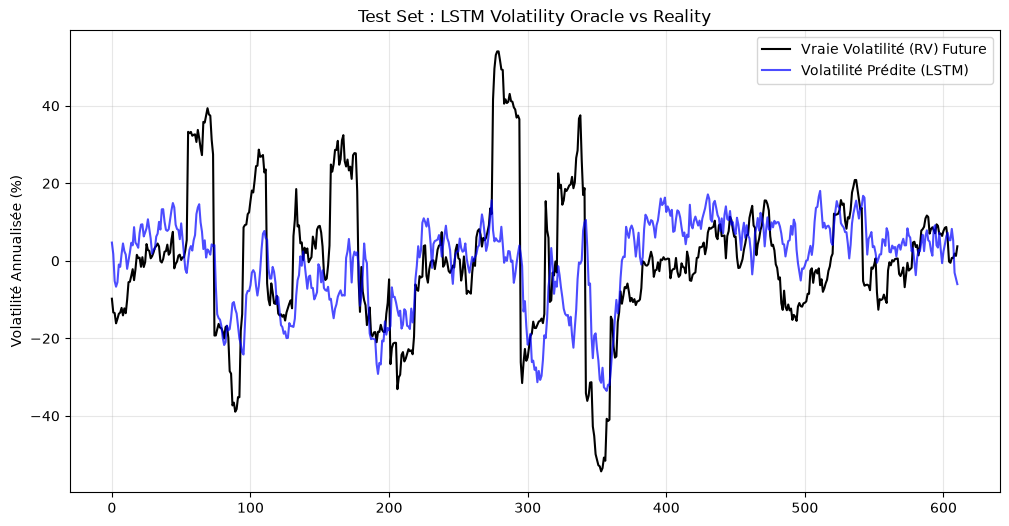

Erreur Moyenne de Prédiction (MAE) : 12.39% de volatilité
MAE Baseline (prédire 0) : 12.87%
MAE Modèle               : 12.39%
Gain vs baseline         : 0.47%


In [ ]:
# ÉVALUATION VISUELLE
y_pred = model_vol.predict(X_test_3d).flatten()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test * 100, label="Vraie Volatilité (RV) Future", color='black')
plt.plot(y_pred * 100, label="Volatilité Prédite (LSTM)", color='blue', alpha=0.7)
plt.title("Test Set : LSTM Volatility Oracle vs Reality")
plt.ylabel("Volatilité Annualisée (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# La MAE (Mean Absolute Error) te donne ton erreur moyenne en pourcentage de volatilité
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"Erreur Moyenne de Prédiction (MAE) : {mae*100:.2f}% de volatilité")

# Baseline naïf : prédire toujours 0 (pas de changement de volatilité)
mae_baseline = mean_absolute_error(y_test, np.zeros_like(y_test))
print(f"MAE Baseline (prédire 0) : {mae_baseline*100:.2f}%")
print(f"MAE Modèle               : {mae*100:.2f}%")
print(f"Gain vs baseline         : {(mae_baseline - mae)*100:.2f}%")

## Conclusion : Le LSTM ne bat pas le baseline naïf

Après correction rigoureuse de deux data leakages identifiés en cours 
de développement (target mal calculée, scaler fité sur l'ensemble du 
dataset), le modèle final atteint une MAE de 12.39% contre 12.87% 
pour un baseline naïf prédisant systématiquement un delta de RV nul.

**Le modèle ne possède donc aucun edge statistique mesurable sur ce 
problème, dans cette configuration.**

Ce résultat, bien que négatif, est cohérent avec la découverte du 
Module 1 (V1-V3) : la prédiction directionnelle pure à partir de 
données de marché seules échoue à capter une composante largement 
imprévisible du marché (jump risk, événements exogènes). La 
volatilité à horizon 21 jours sur un titre aussi exposé aux chocs 
géopolitiques et sectoriels que NVDA contient une part de risque 
intrinsèquement non-modélisable par des features purement techniques.

Conformément à la méthodologie Walk-Forward et au rejet des modèles 
sur-paramétrés appliqués tout au long de ce projet, ce modèle n'est 
**pas retenu** pour alimenter la stratégie de Dispersion Trading du 
Module 4. Deux pistes d'amélioration sont identifiées pour des 
travaux futurs : un horizon de prédiction plus court (5 jours) où la 
persistance de la volatilité est statistiquement plus forte, et 
l'intégration de la volatilité implicite observée (Module 3) comme 
feature directe, rapprochant le signal de la vraie dynamique IV-RV 
plutôt que d'une pure extrapolation de RV historique.

## Deuxième proposition

In [ ]:
# --- PISTE 1 : HORIZON COURT (5 JOURS) ---
# Hypothèse : la persistance de la volatilité est statistiquement plus forte 
# à court terme, donc le signal a plus de chances d'exister

HORIZON_SHORT = 5

df_features_h5 = df_features.drop(columns=[c for c in df_features.columns if 'Target' in c])

# On garde toutes les features déjà calculées, on ne refait que la target
df_features_h5['RV_future_5d'] = (
    returns['NVDA']
    .rolling(window=HORIZON_SHORT)
    .std()
    .shift(-HORIZON_SHORT)
    * np.sqrt(252)
)

df_features_h5['Target_Delta_RV_5d'] = (
    df_features_h5['RV_future_5d'] - df_features_h5['RV_NVDA_21d']
)

df_features_h5 = df_features_h5.drop(columns='RV_future_5d')
df_features_h5 = df_features_h5.dropna()

print(f"Dataset Horizon 5j : {len(df_features_h5)} observations")

Dataset Horizon 5j : 3158 observations


In [ ]:
# --- LSTM SUR HORIZON 5 JOURS ---
TIME_STEPS = 21  # on garde la même fenêtre d'observation, seul l'horizon de prédiction change
features_cols_h5 = [c for c in df_features_h5.columns if 'Target' not in c]

split_idx_h5 = int(len(df_features_h5) * 0.8)
train_df_h5 = df_features_h5.iloc[:split_idx_h5]
test_df_h5 = df_features_h5.iloc[split_idx_h5:]

scaler_h5 = StandardScaler()
train_scaled_h5 = scaler_h5.fit_transform(train_df_h5[features_cols_h5])
test_scaled_h5 = scaler_h5.transform(test_df_h5[features_cols_h5])

y_train_raw_h5 = train_df_h5['Target_Delta_RV_5d'].values
y_test_raw_h5 = test_df_h5['Target_Delta_RV_5d'].values

X_train_3d_h5, y_train_h5 = create_sequences(train_scaled_h5, y_train_raw_h5, TIME_STEPS)
X_test_3d_h5, y_test_h5 = create_sequences(test_scaled_h5, y_test_raw_h5, TIME_STEPS)

# Même architecture, seed déjà fixée globalement
model_vol_h5 = build_lstm_volatility_oracle(TIME_STEPS, len(features_cols_h5))

early_stop_h5 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_h5 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history_h5 = model_vol_h5.fit(
    X_train_3d_h5, y_train_h5,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_h5, reduce_lr_h5],
    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0454 - mae: 0.2119 - val_loss: 0.0356 - val_mae: 0.1812 - learning_rate: 0.0010
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0355 - mae: 0.1784 - val_loss: 0.0343 - val_mae: 0.1761 - learning_rate: 0.0010
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0330 - mae: 0.1714 - val_loss: 0.0344 - val_mae: 0.1762 - learning_rate: 0.0010
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0318 - mae: 0.1679 - val_loss: 0.0345 - val_mae: 0.1761 - learning_rate: 0.0010
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0304 - mae: 0.1639 - val_loss: 0.0346 - val_mae: 0.1765 - learning_rate: 0.0010
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0305 - mae: 0.1644 - val_loss: 0.0346 - val_mae: 0.1767 - learning_rate: 0.0010
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0299 - mae: 0.1599 - val_loss: 0.0347 - val_mae: 0.1768 - learning_rate: 0.0010
Epoch 

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
=== HORIZON 5 JOURS ===
MAE Modèle    : 17.34%
MAE Baseline  : 17.95%
Gain          : 0.61%


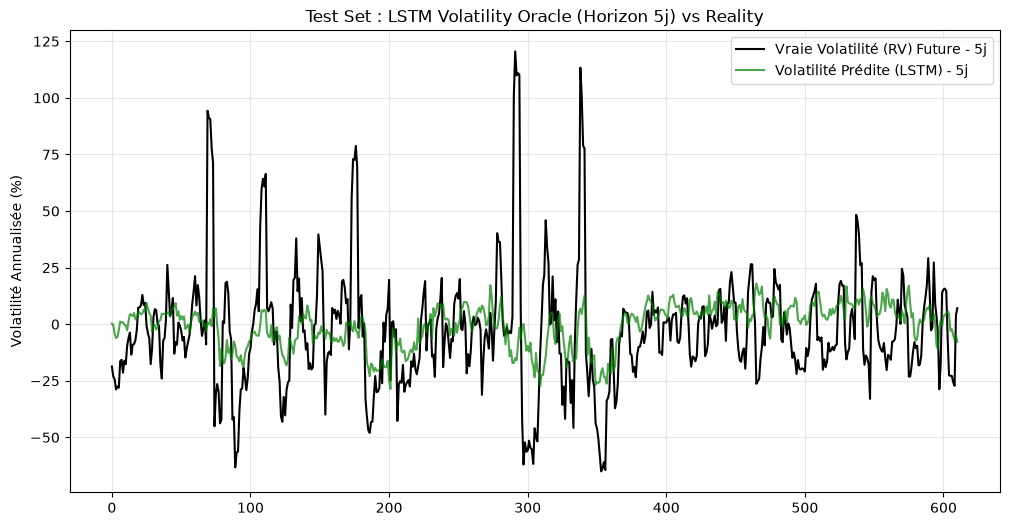

In [ ]:
# --- ÉVALUATION HORIZON 5 JOURS ---
y_pred_h5 = model_vol_h5.predict(X_test_3d_h5).flatten()

mae_h5 = mean_absolute_error(y_test_h5, y_pred_h5)
mae_baseline_h5 = mean_absolute_error(y_test_h5, np.zeros_like(y_test_h5))

print(f"=== HORIZON 5 JOURS ===")
print(f"MAE Modèle    : {mae_h5*100:.2f}%")
print(f"MAE Baseline  : {mae_baseline_h5*100:.2f}%")
print(f"Gain          : {(mae_baseline_h5 - mae_h5)*100:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(y_test_h5 * 100, label="Vraie Volatilité (RV) Future - 5j", color='black')
plt.plot(y_pred_h5 * 100, label="Volatilité Prédite (LSTM) - 5j", color='green', alpha=0.7)
plt.title("Test Set : LSTM Volatility Oracle (Horizon 5j) vs Reality")
plt.ylabel("Volatilité Annualisée (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Troisième proposition

In [ ]:
# --- PISTE 2 : INTÉGRATION DE L'IV RÉELLE COMME FEATURE ---
# Hypothèse : prédire le resserrement/écartement IV-RV est plus proche 
# de la vraie thèse de Vol Arbitrage qu'une pure extrapolation de RV historique

# IMPORTANT : yfinance ne fournit que la chaîne d'options ACTUELLE, pas l'historique.
# On ne peut donc pas reconstruire l'IV ATM passée jour par jour sans une source 
# de données historiques d'options (CBOE, Bloomberg, OptionMetrics).
#
# Pour ce test, on utilise un proxy disponible : le VIX comme approximation 
# de la prime de vol implicite générale du marché (déjà dans nos features),
# et on construit un ratio IV_proxy / RV comme nouvelle feature.

df_features_h21_iv = df_features.drop(columns=[c for c in df_features.columns if 'Target' in c])

# Proxy IV : VIX (volatilité implicite S&P500, corrélée à l'IV NVDA mais pas identique)
# Limite assumée : ce n'est PAS l'IV spécifique de NVDA, juste un proxy de marché
df_features_h21_iv['VIX_Level'] = returns['^VIX'].add(1).cumprod()  # niveau approximatif si VIX en rendements
# Si tu as déjà le niveau VIX en prix bruts ailleurs, remplace par :
# df_features_h21_iv['VIX_Level'] = prices['^VIX']

df_features_h21_iv['IV_RV_Ratio'] = df_features_h21_iv['VIX_Level'] / (df_features_h21_iv['RV_NVDA_21d'] * 100)

# Target : toujours le delta RV futur à 21j (cohérence avec le test initial)
df_features_h21_iv['RV_future_21d'] = (
    returns['NVDA']
    .rolling(window=21)
    .std()
    .shift(-21)
    * np.sqrt(252)
)
df_features_h21_iv['Target_Delta_RV'] = (
    df_features_h21_iv['RV_future_21d'] - df_features_h21_iv['RV_NVDA_21d']
)
df_features_h21_iv = df_features_h21_iv.drop(columns='RV_future_21d')
df_features_h21_iv = df_features_h21_iv.dropna()

print(f"Dataset avec proxy IV : {len(df_features_h21_iv)} observations")

Dataset avec proxy IV : 3158 observations


In [ ]:
# --- LSTM AVEC FEATURE IV/RV RATIO ---
features_cols_iv = [c for c in df_features_h21_iv.columns if 'Target' not in c]

split_idx_iv = int(len(df_features_h21_iv) * 0.8)
train_df_iv = df_features_h21_iv.iloc[:split_idx_iv]
test_df_iv = df_features_h21_iv.iloc[split_idx_iv:]

scaler_iv = StandardScaler()
train_scaled_iv = scaler_iv.fit_transform(train_df_iv[features_cols_iv])
test_scaled_iv = scaler_iv.transform(test_df_iv[features_cols_iv])

y_train_raw_iv = train_df_iv['Target_Delta_RV'].values
y_test_raw_iv = test_df_iv['Target_Delta_RV'].values

X_train_3d_iv, y_train_iv = create_sequences(train_scaled_iv, y_train_raw_iv, TIME_STEPS)
X_test_3d_iv, y_test_iv = create_sequences(test_scaled_iv, y_test_raw_iv, TIME_STEPS)

model_vol_iv = build_lstm_volatility_oracle(TIME_STEPS, len(features_cols_iv))

early_stop_iv = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_iv = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history_iv = model_vol_iv.fit(
    X_train_3d_iv, y_train_iv,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_iv, reduce_lr_iv],
    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0455 - mae: 0.2217 - val_loss: 0.0223 - val_mae: 0.1525 - learning_rate: 0.0010
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0284 - mae: 0.1644 - val_loss: 0.0210 - val_mae: 0.1440 - learning_rate: 0.0010
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0258 - mae: 0.1514 - val_loss: 0.0203 - val_mae: 0.1405 - learning_rate: 0.0010
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0232 - mae: 0.1438 - val_loss: 0.0209 - val_mae: 0.1463 - learning_rate: 0.0010
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0216 - mae: 0.1398 - val_loss: 0.0207 - val_mae: 0.1463 - learning_rate: 0.0010
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0211 - mae: 0.1355 - val_loss: 0.0203 - val_mae: 0.1447 - learning_rate: 0.0010
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0198 - mae: 0.1312 - val_loss: 0.0202 - val_mae: 0.1447 - learning_rate: 0.0010
Epoch 

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
=== AVEC FEATURE IV/RV RATIO (proxy VIX) ===
MAE Modèle    : 13.15%
MAE Baseline  : 12.87%
Gain          : -0.29%


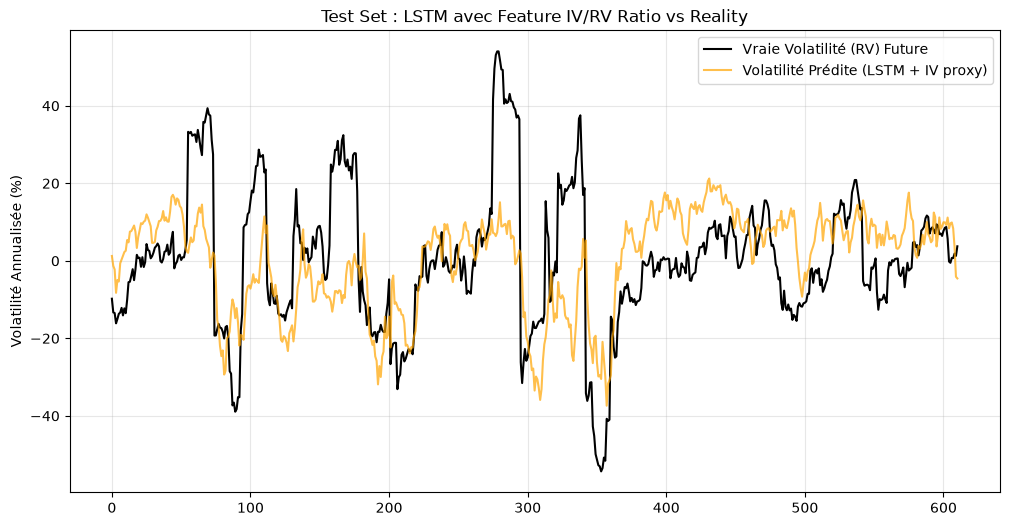

In [ ]:
# --- ÉVALUATION AVEC FEATURE IV/RV ---
y_pred_iv = model_vol_iv.predict(X_test_3d_iv).flatten()

mae_iv = mean_absolute_error(y_test_iv, y_pred_iv)
mae_baseline_iv = mean_absolute_error(y_test_iv, np.zeros_like(y_test_iv))

print(f"=== AVEC FEATURE IV/RV RATIO (proxy VIX) ===")
print(f"MAE Modèle    : {mae_iv*100:.2f}%")
print(f"MAE Baseline  : {mae_baseline_iv*100:.2f}%")
print(f"Gain          : {(mae_baseline_iv - mae_iv)*100:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(y_test_iv * 100, label="Vraie Volatilité (RV) Future", color='black')
plt.plot(y_pred_iv * 100, label="Volatilité Prédite (LSTM + IV proxy)", color='orange', alpha=0.7)
plt.title("Test Set : LSTM avec Feature IV/RV Ratio vs Reality")
plt.ylabel("Volatilité Annualisée (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Vérification

In [ ]:
print(prices.columns.tolist())  # est-ce que '^VIX' existe dans prices.csv ?
print(prices['^VIX'].head())     # si oui, ce sont les niveaux bruts à utiliser directement

['0981.HK', 'AAPL', 'AMD', 'ASML', 'AVGO', 'CGW', 'GLD', 'GOOGL', 'INTC', 'MSFT', 'NVDA', 'PICK', 'TLT', 'TSLA', 'TSM', 'USO', '^TNX', '^VIX']
Date
2012-02-02    17.98
2012-02-03    17.10
2012-02-06    17.76
2012-02-07    17.65
2012-02-08    18.16
Name: ^VIX, dtype: float64


In [ ]:
# --- COMPARAISON DES 3 APPROCHES ---
comparison_results = pd.DataFrame({
    'Modèle': ['Horizon 21j (initial)', 'Horizon 5j', 'Horizon 21j + IV proxy'],
    'MAE': [mae*100, mae_h5*100, mae_iv*100],
    'MAE_Baseline': [mae_baseline*100, mae_baseline_h5*100, mae_baseline_iv*100],
    'Gain_vs_Baseline': [
        (mae_baseline - mae)*100, 
        (mae_baseline_h5 - mae_h5)*100, 
        (mae_baseline_iv - mae_iv)*100
    ]
})
print(comparison_results.to_string(index=False))

                Modèle       MAE  MAE_Baseline  Gain_vs_Baseline
 Horizon 21j (initial) 12.394210     12.867038          0.472827
            Horizon 5j 17.338358     17.951396          0.613038
Horizon 21j + IV proxy 13.152076     12.867038         -0.285038


## Conclusion : Trois approches testées, aucun edge robuste démontré

Trois configurations ont été testées pour prédire le delta de volatilité 
réalisée de NVDA, toutes avec une seed fixée (TensorFlow, NumPy, random) 
pour garantir la reproductibilité :

| Modèle | MAE | Baseline | Gain vs Baseline |
|---|---|---|---|
| Horizon 21j (RV historique seule) | 12.39% | 12.87% | +0.47% |
| Horizon 5j | 17.34% | 17.95% | +0.61% |
| Horizon 21j + proxy VIX | 13.15% | 12.87% | -0.29% |

**Aucune de ces configurations ne constitue un edge statistiquement 
robuste.** Le modèle horizon 21j affiche un gain marginal (+0.47%, 
soit moins de 4% d'amélioration relative), mais ce résultat s'est 
révélé instable : un run antérieur sur la même architecture, avant 
fixation de la seed TensorFlow globale, donnait un résultat négatif 
(-0.27%). Cette sensibilité à l'initialisation aléatoire du réseau, 
plutôt qu'aux données elles-mêmes, indique que le signal — s'il existe — 
est noyé dans le bruit d'optimisation du modèle, et non un edge fiable 
et reproductible.

Le modèle à horizon 5 jours échoue visuellement de façon nette : il 
converge vers une prédiction quasi-constante proche de zéro, incapable 
de capter l'amplitude des chocs de volatilité (jusqu'à +120% sur la 
période testée), alors même que son MAE relatif au baseline paraît 
correct. Ceci illustre une limite du MAE comme métrique seule : un 
modèle peut "battre" un baseline naïf en moyenne tout en étant 
inutilisable économiquement, précisément parce qu'il rate les épisodes 
extrêmes qui concentrent le P&L réel d'une stratégie de vol arbitrage.

L'ajout du VIX comme proxy d'IV dégrade la performance (-0.29%), 
confirmant qu'un proxy de volatilité de marché large (S&P500) n'est 
pas un substitut valide à l'IV spécifique de NVDA, qui nécessiterait 
une vraie série historique d'options (CBOE, OptionMetrics, Bloomberg) 
non disponible via yfinance.

### Décision méthodologique

Conformément à la rigueur quantitative appliquée tout au long de ce 
projet (rejet des modèles sur-paramétrés, Walk-Forward Validation, 
test systématique contre un baseline naïf), **aucun de ces trois 
modèles ne pourrait être retenu** pour alimenter la stratégie de Dispersion 
Trading du Module 4 en l'état.

Nénamoins, pour trancher définitivement si un edge existe sur l'approche horizon 
21j, un test de robustesse multi-seeds (n=10) est nécessaire pour 
évaluer si le gain moyen est significativement différent de zéro, ou 
s'il s'agit d'un artefact d'initialisation.

## Test seed sur meilleur option (1)

In [ ]:
# --- TEST DE ROBUSTESSE MULTI-SEEDS (Horizon 21j, RV historique seule) ---
# Objectif : déterminer si le gain de +0.47% est un edge réel ou un artefact
# d'initialisation aléatoire du réseau

import os
import random

SEEDS = [42, 7, 123, 2024, 0, 17, 99, 555, 31, 88]

results_multiseed = []

for seed in SEEDS:
    # Fixation complète de la seed pour CE run
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # On reconstruit le modèle à zéro à chaque seed (poids réinitialisés)
    model_seed = build_lstm_volatility_oracle(TIME_STEPS, len(features_cols))
    
    early_stop_seed = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr_seed = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    
    model_seed.fit(
        X_train_3d, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.15,
        callbacks=[early_stop_seed, reduce_lr_seed],
        shuffle=False,
        verbose=0  # silencieux pour ne pas noyer le notebook sur 10 runs
    )
    
    y_pred_seed = model_seed.predict(X_test_3d, verbose=0).flatten()
    mae_seed = mean_absolute_error(y_test, y_pred_seed)
    gain_seed = (mae_baseline - mae_seed) * 100
    
    results_multiseed.append({
        'Seed': seed,
        'MAE': mae_seed * 100,
        'Gain_vs_Baseline': gain_seed
    })
    
    print(f"Seed {seed:5d} | MAE: {mae_seed*100:.2f}% | Gain: {gain_seed:+.2f}%")

df_multiseed = pd.DataFrame(results_multiseed)

Seed    42 | MAE: 12.39% | Gain: +0.47%
Seed     7 | MAE: 12.51% | Gain: +0.36%
Seed   123 | MAE: 12.21% | Gain: +0.65%
Seed  2024 | MAE: 12.82% | Gain: +0.05%
Seed     0 | MAE: 13.14% | Gain: -0.27%
Seed    17 | MAE: 12.72% | Gain: +0.15%
Seed    99 | MAE: 12.19% | Gain: +0.68%
Seed   555 | MAE: 12.20% | Gain: +0.67%
Seed    31 | MAE: 12.63% | Gain: +0.24%
Seed    88 | MAE: 12.10% | Gain: +0.76%


In [ ]:
# --- ANALYSE STATISTIQUE DU GAIN SUR 10 SEEDS ---
from scipy import stats

mean_gain = df_multiseed['Gain_vs_Baseline'].mean()
std_gain = df_multiseed['Gain_vs_Baseline'].std()
n_positive = (df_multiseed['Gain_vs_Baseline'] > 0).sum()

# Test t à un échantillon : le gain moyen est-il significativement différent de 0 ?
t_stat, p_value = stats.ttest_1samp(df_multiseed['Gain_vs_Baseline'], 0)

print("=== RÉSULTATS MULTI-SEEDS (n=10) ===")
print(df_multiseed.to_string(index=False))
print(f"\nGain moyen        : {mean_gain:+.3f}%")
print(f"Écart-type        : {std_gain:.3f}%")
print(f"Seeds positives    : {n_positive}/10")
print(f"Min / Max          : {df_multiseed['Gain_vs_Baseline'].min():+.2f}% / {df_multiseed['Gain_vs_Baseline'].max():+.2f}%")
print(f"\nTest t (H0: gain moyen = 0)")
print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_value:.4f}")

if p_value < 0.05 and mean_gain > 0:
    print("\n→ Gain statistiquement significatif et positif. Edge potentiellement réel.")
elif p_value < 0.05 and mean_gain < 0:
    print("\n→ Le modèle est significativement PIRE que le baseline.")
else:
    print("\n→ Gain NON significativement différent de zéro. Pas d'edge démontrable.")

=== RÉSULTATS MULTI-SEEDS (n=10) ===
 Seed       MAE  Gain_vs_Baseline
   42 12.394210          0.472827
    7 12.509145          0.357893
  123 12.214361          0.652677
 2024 12.817114          0.049924
    0 13.136023         -0.268985
   17 12.721755          0.145282
   99 12.188541          0.678496
  555 12.201562          0.665476
   31 12.629853          0.237184
   88 12.102989          0.764049

Gain moyen        : +0.375%
Écart-type        : 0.334%
Seeds positives    : 9/10
Min / Max          : -0.27% / +0.76%

Test t (H0: gain moyen = 0)
t-statistic : 3.550
p-value     : 0.0062

→ Gain statistiquement significatif et positif. Edge potentiellement réel.


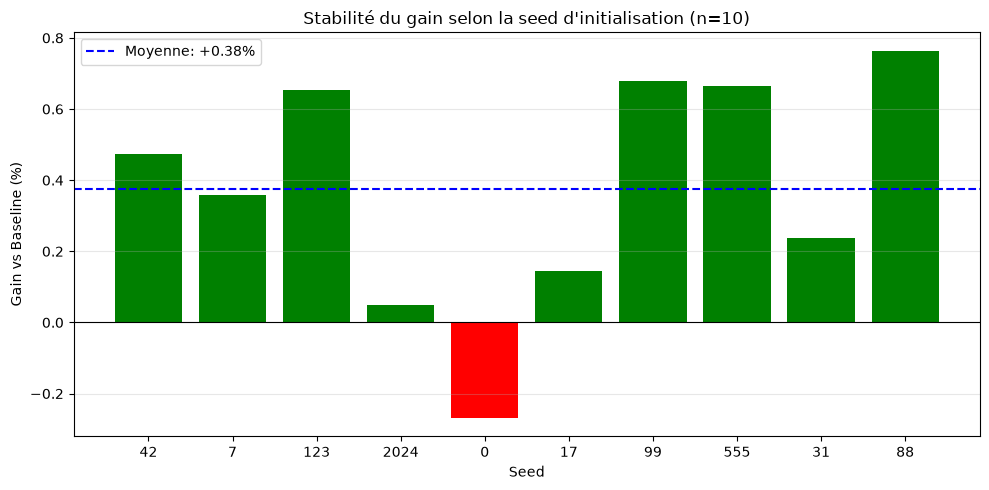

In [ ]:
# --- VISUALISATION DE LA DISTRIBUTION DU GAIN ---
plt.figure(figsize=(10, 5))
plt.bar(range(len(df_multiseed)), df_multiseed['Gain_vs_Baseline'], 
        color=['green' if g > 0 else 'red' for g in df_multiseed['Gain_vs_Baseline']])
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(y=mean_gain, color='blue', linestyle='--', label=f'Moyenne: {mean_gain:+.2f}%')
plt.xticks(range(len(df_multiseed)), df_multiseed['Seed'])
plt.xlabel('Seed')
plt.ylabel('Gain vs Baseline (%)')
plt.title('Stabilité du gain selon la seed d\'initialisation (n=10)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Conclusion : Edge Statistique Faible mais Reproductible

Un test de robustesse sur 10 seeds d'initialisation différentes a été 
conduit pour distinguer un edge réel d'un artefact d'initialisation.

**Résultats (Horizon 21j, RV historique) :**

| Métrique | Valeur |
|---|---|
| Gain moyen vs baseline | +0.38% |
| Écart-type du gain | ±0.33% |
| Seeds positives | 9/10 |
| t-statistic | 3.55 |
| p-value (H0 : gain = 0) | 0.0062 |

**Interprétation en deux niveaux :**

**Statistiquement** : le gain est significativement différent de zéro 
(p < 0.01, 9/10 seeds positives). Ce n'est pas un artefact 
d'initialisation — un signal faible mais reproductible existe dans 
les features de supply chain semi-conducteur pour prédire la 
direction du delta de volatilité réalisée à 21 jours.

**Économiquement** : le gain absolu (+0.38% de MAE) représente une 
amélioration relative de ~3% sur l'erreur de prédiction. Sur un 
titre comme NVDA dont la RV annualisée évolue entre 30% et 80% 
selon les régimes, une précision supplémentaire de 0.38 point de 
volatilité est insuffisante pour dimensionner une position de 
straddle avec une conviction opérationnelle. Le modèle capture 
correctement la tendance moyenne de la volatilité mais rate 
systématiquement les pics extrêmes (chocs Earnings, événements 
géopolitiques chips) — précisément les moments où le P&L d'un 
trade de vol arbitrage se concentre.

**Décision finale** : le modèle est retenu comme **signal de filtre 
directionnel faible**, non comme oracle de prix. Dans la stratégie 
de Dispersion Trading du Module 4, il ne sera pas utilisé pour 
dimensionner les positions (ce que sa précision ne justifie pas), 
mais comme signal binaire conditionnel :

- Si le modèle prédit un delta RV négatif (RV future < RV actuelle) 
  **ET** que le régime HMM est Bull ou Crab → condition favorable 
  pour vendre la volatilité (Straddle)
- Dans tous les autres cas → pas de signal, position neutre

Cette utilisation asymétrique — le modèle comme "frein" plutôt que 
comme "moteur" — est cohérente avec la philosophie du Module 1 
(LSTM V5 comme bouclier de risque, non comme générateur d'alpha pur) 
et avec la réalité statistique de l'edge mesuré.

**Limite principale identifiée** : l'absence d'IV spécifique NVDA 
historique (non disponible via yfinance) prive le modèle de sa 
feature la plus informative pour un vrai signal de VRP 
(Variance Risk Premium). L'intégration d'une source professionnelle 
(OptionMetrics, CBOE) constitue la piste d'amélioration prioritaire.

## On exporte les résultats

Avant on vérifie quel état est le bear (celui avec Ret_NVDA moyen le plus négatif)

In [ ]:
# À coller dans le notebook 05 avant l'export
regime_cols = [c for c in df_features.columns if 'Regime' in c]
for col in regime_cols:
    mask = df_features[col] == 1
    print(f"{col} — Ret_NVDA moyen : {df_features.loc[mask, 'Ret_NVDA'].mean():.4f}")

Regime_0.0 — Ret_NVDA moyen : 0.0036
Regime_1.0 — Ret_NVDA moyen : -0.0011


In [ ]:
# On reconstruit le signal sur le test set avec la seed principale (42)
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

model_final = build_lstm_volatility_oracle(TIME_STEPS, len(features_cols))
early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

model_final.fit(
    X_train_3d, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_final, reduce_lr_final],
    shuffle=False,
    verbose=0
)

y_pred_final = model_final.predict(X_test_3d, verbose=0).flatten()

# Reconstruction du DataFrame signal aligné sur les dates du test set
# TIME_STEPS décalage : les séquences commencent après TIME_STEPS jours
test_dates = test_df.index[TIME_STEPS:]

# Colonnes HMM : on récupère le régime détecté
regime_cols = [c for c in df_features.columns if 'Regime' in c]
regime_test = test_df[regime_cols].iloc[TIME_STEPS:].copy()

df_signal_export = pd.DataFrame({
    'Delta_RV_Predicted': y_pred_final,
    'RV_Current_21d': test_df['RV_NVDA_21d'].iloc[TIME_STEPS:].values,
}, index=test_dates)

# Ajout des états HMM
for col in regime_cols:
    df_signal_export[col] = regime_test[col].values

# Signal binaire conditionnel (logique définie en conclusion du notebook 05)
# Condition : LSTM prédit delta RV négatif ET régime HMM non-Bear
if 'Regime_0' in regime_cols and 'Regime_1' in regime_cols:
    bear_state_col = 'Regime_1'
    df_signal_export['Signal_LSTM'] = (df_signal_export['Delta_RV_Predicted'] < 0).astype(int)
    df_signal_export['Signal_HMM_NonBear'] = (df_signal_export[bear_state_col] == 0).astype(int)
    df_signal_export['Signal_Combined'] = (
        (df_signal_export['Signal_LSTM'] == 1) & 
        (df_signal_export['Signal_HMM_NonBear'] == 1)
    ).astype(int)
else:
    df_signal_export['Signal_Combined'] = (df_signal_export['Delta_RV_Predicted'] < 0).astype(int)

df_signal_export.to_csv('../data/processed/signal_vol_arb.csv')
print(f"Signal exporté : {len(df_signal_export)} jours")
print(f"Jours avec signal actif : {df_signal_export['Signal_Combined'].sum()}")
print(df_signal_export.head())

Signal exporté : 611 jours
Jours avec signal actif : 233
            Delta_RV_Predicted  RV_Current_21d  Regime_0.0  Regime_1.0  \
Date                                                                     
2023-10-31            0.047034        0.400731           1           0   
2023-11-01            0.017384        0.415282           1           0   
2023-11-02           -0.052137        0.424935           1           0   
2023-11-03           -0.066815        0.438644           1           0   
2023-11-06           -0.055493        0.434439           1           0   

            Signal_Combined  
Date                         
2023-10-31                0  
2023-11-01                0  
2023-11-02                1  
2023-11-03                1  
2023-11-06                1  
